In [1]:
from src.data_ingestion import dfs, load_from_gcs, train_df, test_df

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
train_df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


In [3]:
train_df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='str')

In [8]:
numeric_t_cols = train_df.select_dtypes(include='number').columns
cat_cols = train_df.select_dtypes(exclude='number').columns
target_var = 'diagnosed_diabetes'
numeric_cols = numeric_t_cols.drop(target_var)


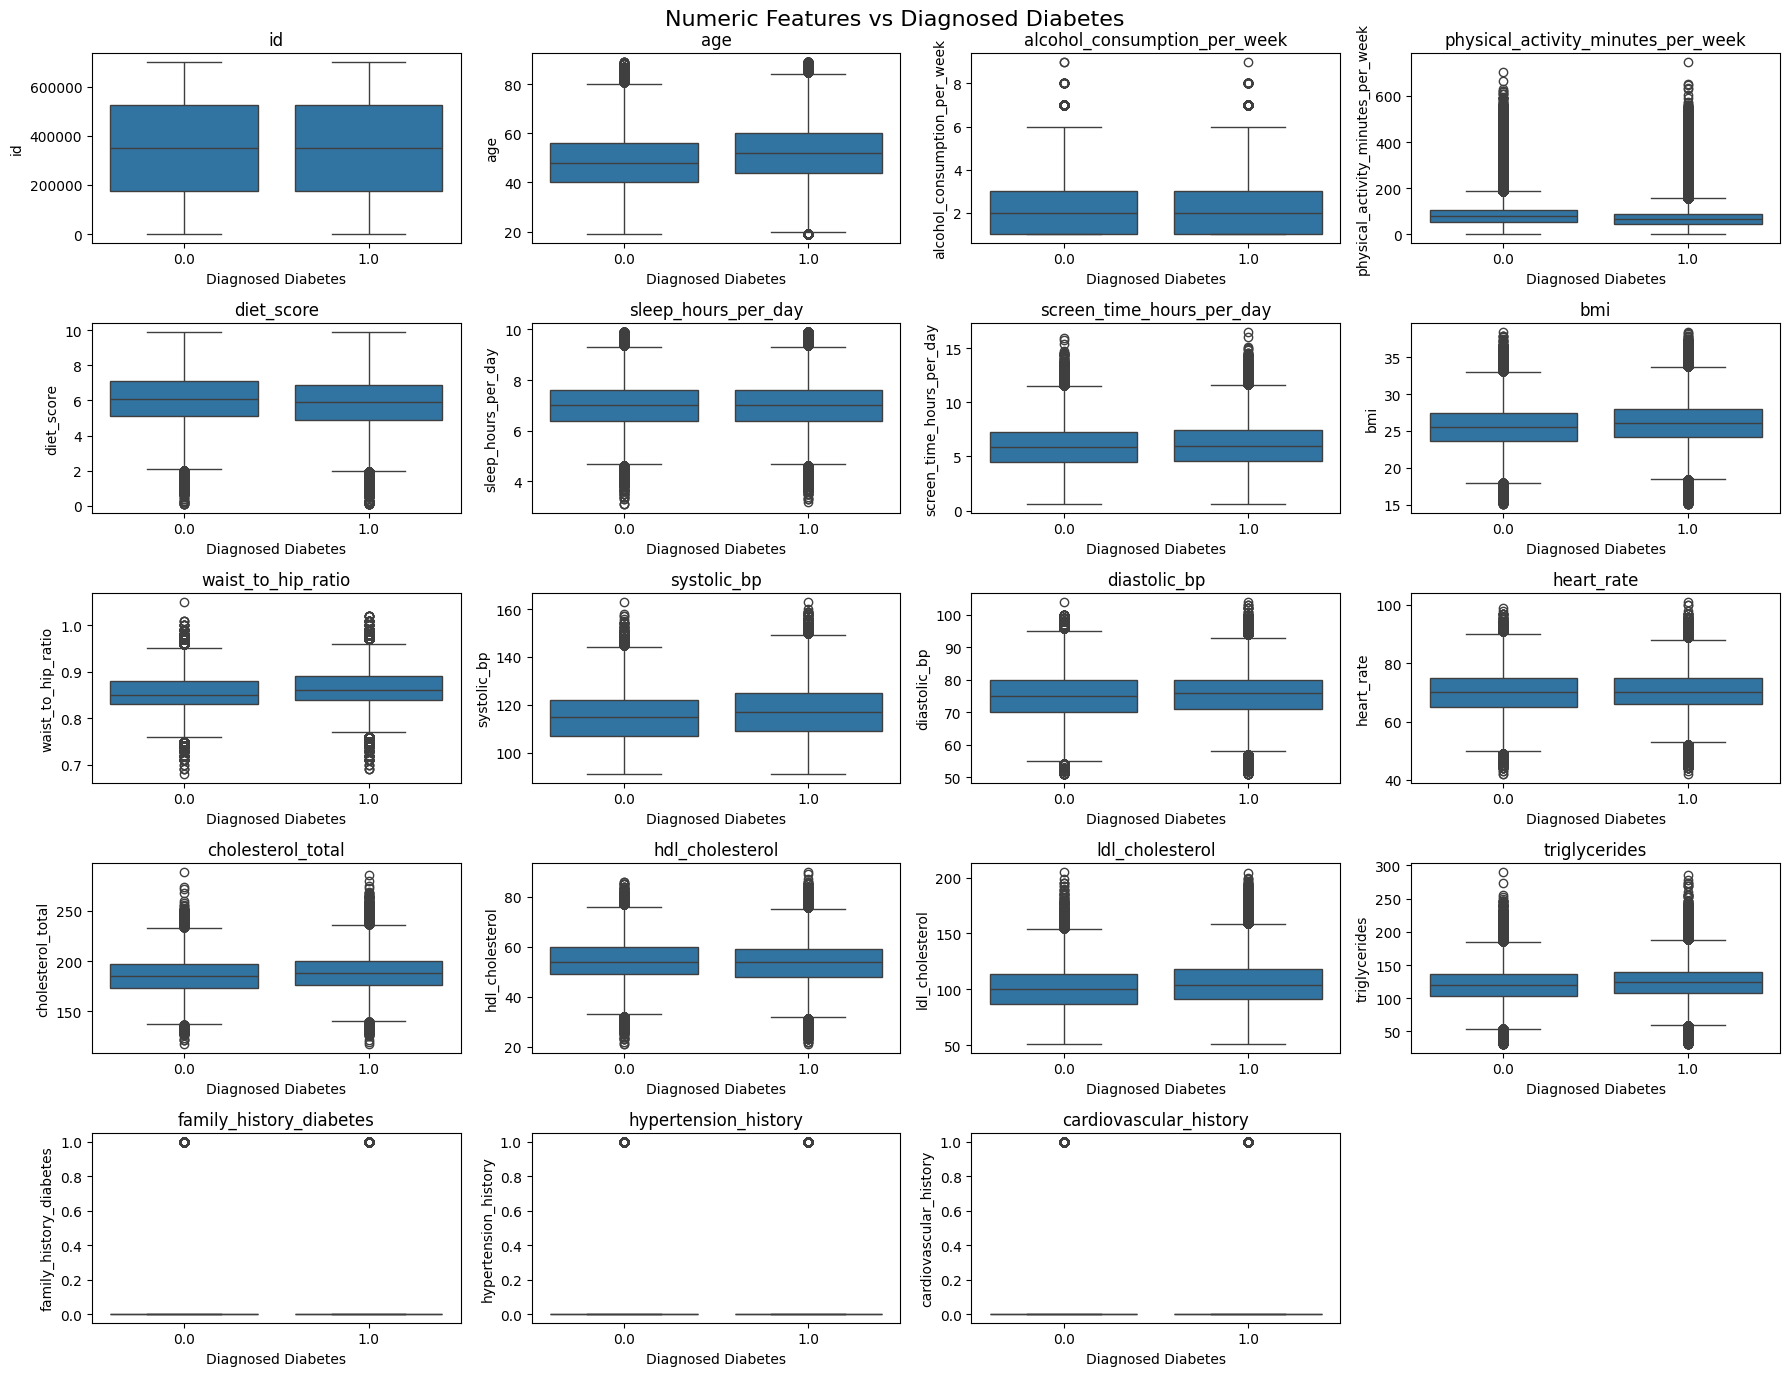

In [ ]:
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=train_df[target_var],
        y=train_df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Diagnosed Diabetes")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Features vs Diagnosed Diabetes", fontsize=16)
plt.tight_layout()
plt.show()


In [17]:
cols = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

for col in cols:
    display(train_df[col].value_counts(normalize=True).round(2).head(10))

family_history_diabetes
0    0.85
1    0.15
Name: proportion, dtype: float64

hypertension_history
0    0.82
1    0.18
Name: proportion, dtype: float64

cardiovascular_history
0    0.97
1    0.03
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Diabetes Based on Family History')

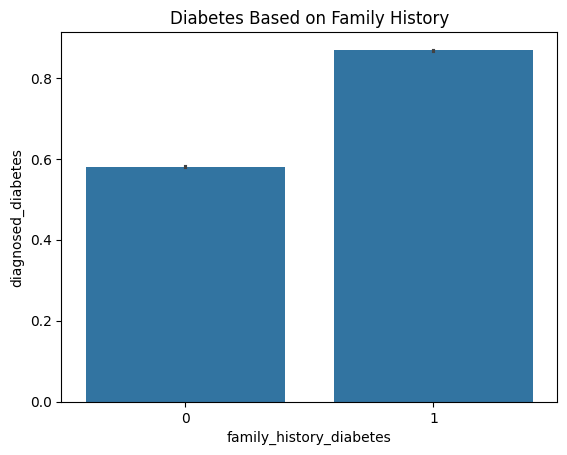

In [20]:
sns.barplot(
    x=train_df['family_history_diabetes'],
    y=train_df[target_var]
)
plt.title("Diabetes Based on Family History")

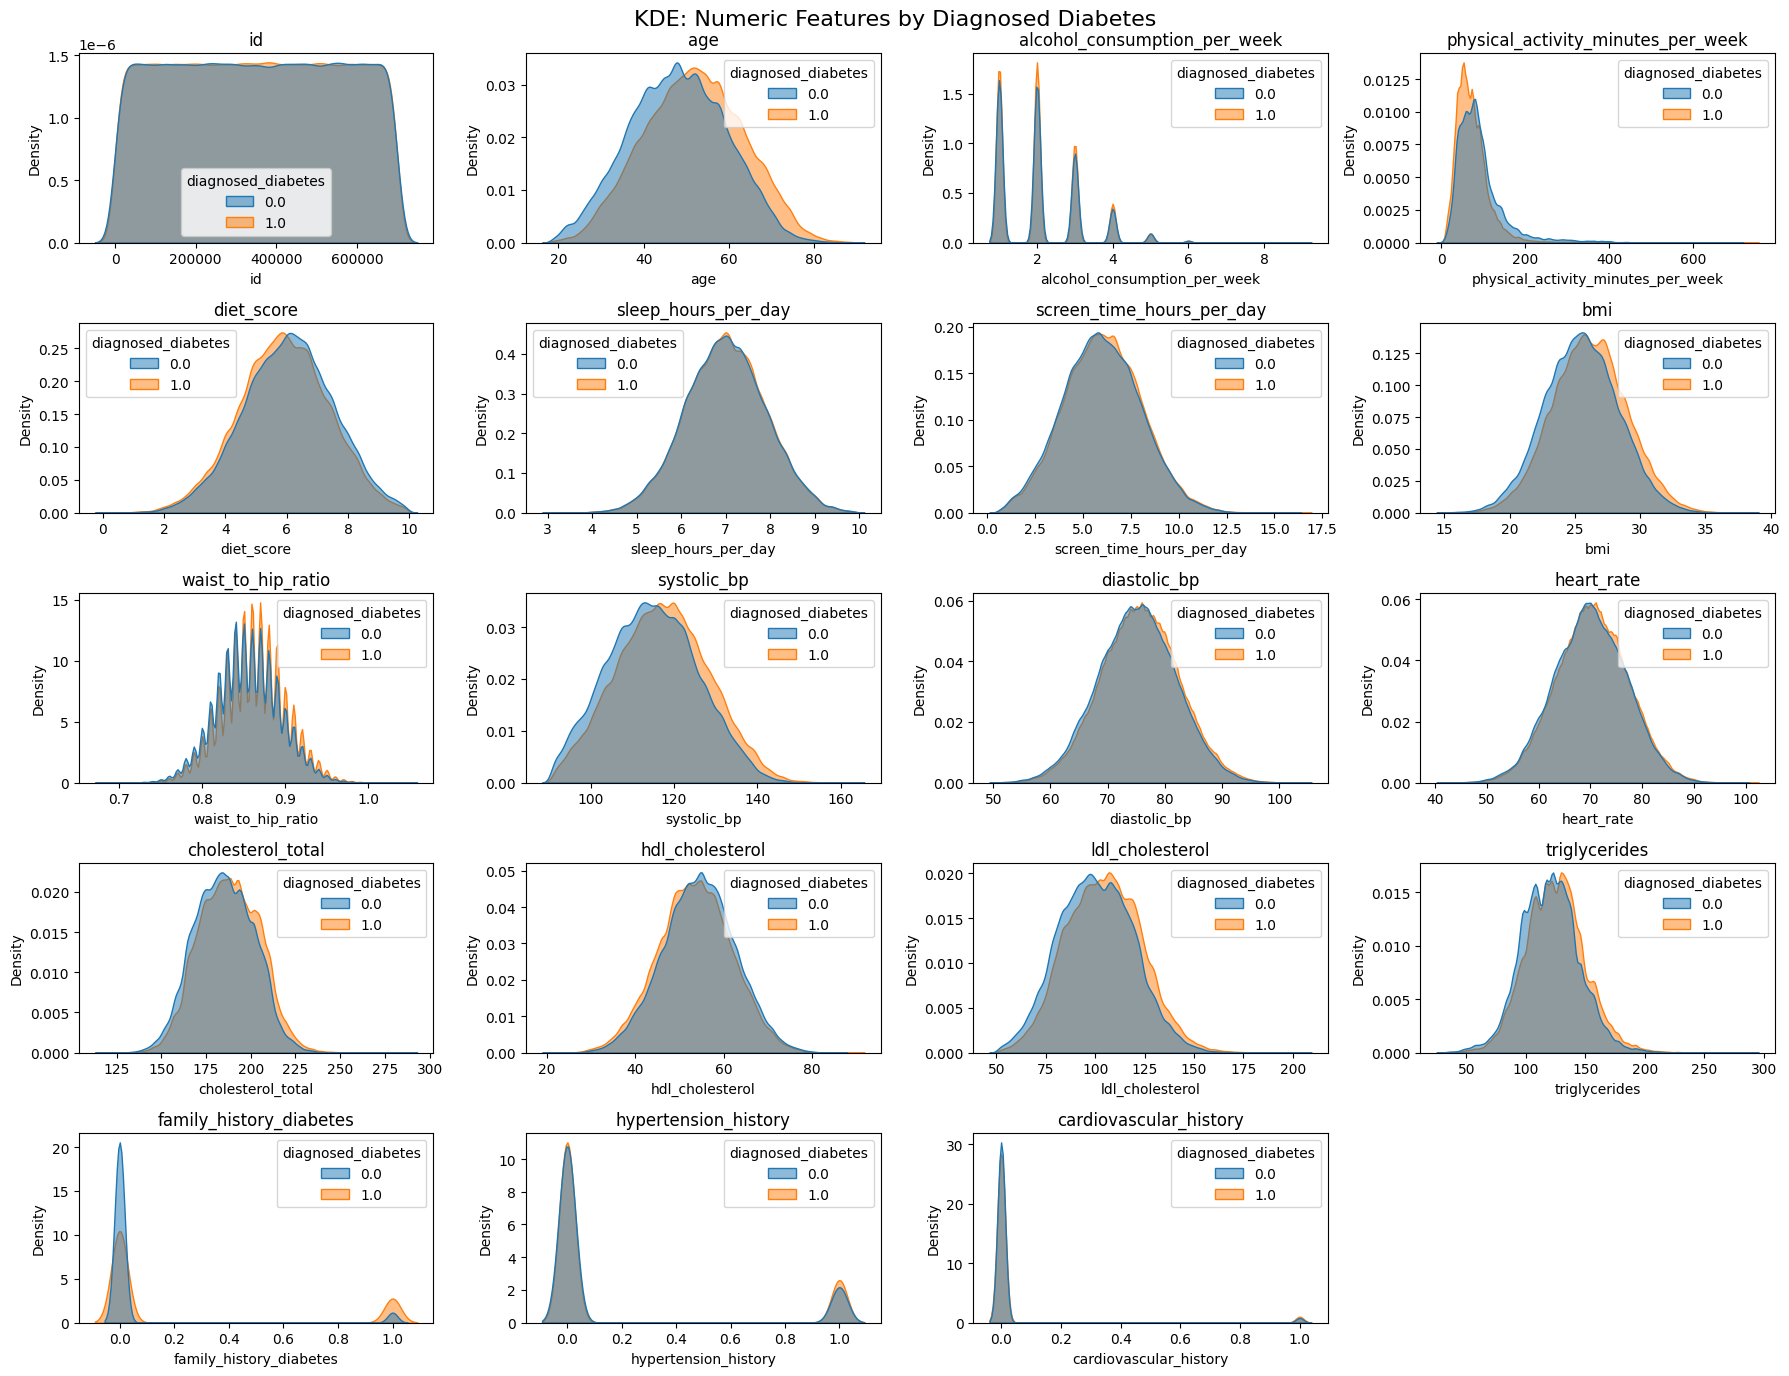

In [ ]:
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=train_df,
        x=col,
        hue=target_var,
        common_norm=False,
        fill=True,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("Density")

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("KDE: Numeric Features by Diagnosed Diabetes", fontsize=16)
plt.tight_layout()
plt.show()
